<a href="https://colab.research.google.com/github/hamedtavakoli/MyColab/blob/main/SSL_SOM_annotated_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SST Pattern Clustering with Self‑Organizing Maps (SOM) using Google Earth Engine (GEE)

This notebook builds **global sea‑surface temperature (SST) anomaly fields** from **NOAA OISST v2.1** via **Google Earth Engine**, regrids them to a coarse, fixed grid (e.g., 2°×2°), and trains a **Self‑Organizing Map (SOM)** to discover recurring **2‑D spatial patterns**. The result is an “atlas” of canonical SST‑anomaly regimes (e.g., El Niño‑like and La Niña‑like structures) and a **time series** mapping each date to its best‑matching pattern.

### What you will get
- A reproducible pipeline to compute **daily or monthly SST anomalies** (1982–2011 baseline), masked for sea‑ice.
- Robust **regridding** from rasters to a **vector grid** with per‑cell means.
- An **SOM** trained on whole‑field anomaly vectors (one vector per date).
- Visualizations of **SOM prototypes** and a **BMU time series** (date → node).

### Recommended workflow
1. Start with **monthly** mode and a short date range to validate the pipeline.
2. Tune `TARGET_DEG` (e.g., 2° or 1°) and the SOM size/iterations for your analysis needs.
3. Scale up to longer periods or daily mode once everything runs smoothly.


## Step 1 — Setting up the environment

Setting up the environment by first installing all the necessary Python libraries using pip. These include **earthengine-api** and **geemap** for interacting with **Google Earth Engine**, minisom for Self-Organizing Maps, and xarray, netCDF4, pandas, numpy, and matplotlib which are common libraries for data manipulation, scientific computing, and plotting.


In [ ]:
# ============================
# Setup: Earth Engine + SOM tools
# ============================
!pip -q install earthengine-api geemap minisom xarray netCDF4 pandas numpy matplotlib

import ee, geemap, numpy as np, pandas as pd, matplotlib.pyplot as plt
from minisom import MiniSom

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Authenticate & initializeing

Authenticate with your Google account and initialize the Earth Engine client. Follow the on-screen link to obtain the token, then paste it back here.


In [ ]:
ee.Authenticate()
ee.Initialize(project="gcmcluster")  # Replace with your actual Google Cloud Project ID

## Step 3 — Experiment Settings
(Time Scale, Value Type, and Anomaly Options)
In this step, we define all high-level switches that control how the dataset is prepared before training the Self-Organising Map (SOM).


In [ ]:
# =========================
# Step 3 — Settings
# =========================

# Time scale of input frames for clustering
# 'daily'  → one frame per day
# 'monthly'→ one frame per calendar month (mean of days)
MODE = 'monthly'   # 'daily' or 'monthly'

# What to feed into the SOM:
# 'sst'   → real SST (°C)
# 'anom'  → anomaly (°C) relative to a 30-year baseline (built-in OR computed)
VALUE_KIND = 'sst'   # 'sst' or 'anom'

# If VALUE_KIND == 'anom', choose the anomaly source.
# 'builtin' → use NOAA OISST v2.1 'anom' band (baseline = 1982–2011 per dataset)
# 'computed'→ compute anomalies yourself from 'sst' with the baseline options below
ANOM_SOURCE = 'computed'   # 'builtin' or 'computed'

# If ANOM_SOURCE == 'computed', define the baseline:
# Temporal dimension of baseline:
#  'monthly' → 12 separate baselines (Jan..Dec)
#  'overall' → a single baseline over the entire baseline period
BASELINE_TEMPORAL = 'monthly'  # 'monthly' or 'overall'

# Spatial dimension of baseline:
#  'per_pixel' → per-pixel climatology (image or 12 images)
#  'global'    → single scalar climatology (or 12 scalars), same everywhere
BASELINE_SPATIAL = 'per_pixel'  # 'per_pixel' or 'global'

# Baseline period when computing anomalies yourself
BASELINE_START = '1982-01-01'
BASELINE_END   = '2011-12-31'

# Ice masking and grid settings
ICE_THRESH = 15.0    # % sea-ice; keep where ice <= this threshold
TARGET_DEG = 4.0     # coarsening to a regular grid for SOM

# Date span for frames to cluster
START = '1982-01-01'
END   = '2011-12-31'

## Step 4 — Build a global vector grid

Creates a **FeatureCollection** of rectangular grid cells (e.g., 2°×2°) covering the globe, each with indices **i, j**. We regrid continuous rasters onto this grid via per-cell means.


In [ ]:
# =========================
# Step 4 — Global vector grid for regridding
# =========================
# Uses TARGET_DEG from Step 3.
# Produces a FeatureCollection where each feature is a lon–lat rectangle
# with attributes:
#   i : column index (0..n_lon-1)
#   j : row index    (0..n_lat-1)

import numpy as np
import ee

def make_vector_grid(step_deg):
    """
    Build a regular lon–lat grid as a FeatureCollection.

    Parameters
    ----------
    step_deg : float
        Grid step in degrees (e.g. 2.0 for ~2° x 2° grid).

    Returns
    -------
    ee.FeatureCollection
        Each feature is a rectangular cell with properties:
        - 'i' : longitude index
        - 'j' : latitude index
    """
    lon_edges = np.arange(-180, 180, step_deg)
    lat_edges = np.arange( -90,  90, step_deg)

    features = []
    for j, lat in enumerate(lat_edges):
        for i, lon in enumerate(lon_edges):
            geom = ee.Geometry.Rectangle([lon, lat, lon + step_deg, lat + step_deg],
                                         geodesic=False)
            feat = ee.Feature(geom, {'i': int(i), 'j': int(j)})
            features.append(feat)

    return ee.FeatureCollection(features)

# Build the grid using TARGET_DEG from Step 3
GRID_FC = make_vector_grid(TARGET_DEG)

print('Number of grid cells:', GRID_FC.size().getInfo())


Number of grid cells: 4050


## Step 5 — Regridding function (reduceRegions mean)

Reduces a single‑band image (e.g., `'anom'`) to the vector grid using **mean** per cell. Returns a small table (**i, j, mean**) suitable for client-side assembly.


In [ ]:
# =========================
# Step 5 — Regridding function (reduceRegions mean)
# =========================
# This function takes an ee.Image (with a single band, e.g. 'sst' or 'anom')
# and reduces it onto the vector grid GRID_FC built in Step 5 (make_vector_grid),
# computing one mean value per cell. It returns a pandas DataFrame with:
#   columns: ['i', 'j', 'mean']
# where i, j are the grid indices and 'mean' is the cell-average value.

import ee
import geemap
import pandas as pd

def regrid_mean(img, grid_fc, band='anom', scale=25000):
    """
    Reduce an image to the vector grid by computing the mean of a band
    inside each grid cell.

    Parameters
    ----------
    img : ee.Image
        Input image with the band of interest (e.g. 'sst' or 'anom').
    grid_fc : ee.FeatureCollection
        FeatureCollection of rectangles with properties 'i' (lon index) and 'j' (lat index).
    band : str, optional
        Name of the band to reduce (default: 'anom').
    scale : float, optional
        Nominal scale in metres for the reduction (default: 25000).

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns:
          - 'i'    : longitude index (int)
          - 'j'    : latitude index (int)
          - 'mean' : mean value of the band in that cell (float)
        Rows with missing 'mean' are dropped.
    """
    # Ensure we have a single-band image of the requested band
    img1 = ee.Image(img).select([band])

    # Per-cell mean over the grid polygons
    red = img1.reduceRegions(
        collection = grid_fc,
        reducer    = ee.Reducer.mean(),
        scale      = scale,
        crs        = 'EPSG:4326',
        tileScale  = 2
    )

    # Convert to pandas DataFrame
    df = geemap.ee_to_df(red)

    # Keep only the columns we care about; rename mean column if needed
    if 'mean' not in df.columns:
        # Sometimes the reducer may name the column as e.g. 'mean' already;
        # this is a safety fallback if the name comes out differently.
        mean_cols = [c for c in df.columns if c.startswith('mean')]
        if mean_cols:
            df = df.rename(columns={mean_cols[0]: 'mean'})

    # Ensure i, j, mean are present
    cols = [c for c in ['i', 'j', 'mean'] if c in df.columns]
    df = df[cols]

    # Drop rows with NaN mean (no valid pixels in that cell)
    df = df.dropna(subset=['mean'])

    # Convert indices to int (important when reshaping later)
    if 'i' in df.columns:
        df['i'] = df['i'].astype(int)
    if 'j' in df.columns:
        df['j'] = df['j'].astype(int)

    return df


## Step 6 — Helper functions: build SST & anomalies

Defines helpers to create daily/monthly **SST (°C)** with sea‑ice masking and to compute the **1982–2011 climatology**. `daily_image()` and `monthly_mean_image()` apply scaling and masks; `clim_month_1982_2011()` returns the monthly climatology.


In [ ]:
# =========================
# Step 6 — Data getters & baselines (clean version)
# =========================
# Uses the settings from Step 3:
#   MODE: 'daily' | 'monthly'
#   VALUE_KIND: 'sst' | 'anom'
#   ANOM_SOURCE: 'builtin' | 'computed'
#   BASELINE_TEMPORAL: 'monthly' | 'overall'
#   BASELINE_SPATIAL:  'per_pixel' | 'global'
#   BASELINE_START, BASELINE_END
#   ICE_THRESH, TARGET_DEG, START, END

import ee
OISST = ee.ImageCollection('NOAA/CDR/OISST/V2_1')

# -------------------------------------------------------------------
# Utilities: scale + mask
# -------------------------------------------------------------------
def _scale_and_mask_sst(img):
    """
    Scale SST to °C and apply a consistent ocean/ice mask.
    Keeps grid cells with: -2 <= sst < 45 °C and ice <= ICE_THRESH (%).
    """
    sstC = img.select('sst').multiply(0.01).rename('sst')           # °C
    iceP = img.select('ice').unmask(0, False).multiply(1)        # %
    mask = sstC.gte(-2).And(sstC.lt(45)).And(iceP.lte(ICE_THRESH))
    return sstC.updateMask(mask)

def _scale_and_mask_anom(img):
    """
    Scale anomaly to °C and apply a broad anomaly mask + ice mask.
    Keeps grid cells with: -10 < anom < 10 °C and ice <= ICE_THRESH (%).
    """
    anomC = img.select('anom').multiply(0.01).rename('anom')        # °C
    iceP  = img.select('ice').unmask(0, False).multiply(1)       # %
    mask  = anomC.gt(-10).And(anomC.lt(10)).And(iceP.lte(ICE_THRESH))
    return anomC.updateMask(mask)

# -------------------------------------------------------------------
# Real SST getters (daily / monthly)
# -------------------------------------------------------------------
def daily_sst_image(date_str):
    """Daily SST (°C) with masking from OISST."""
    d = ee.Date(date_str)
    img = OISST.filterDate(d, d.advance(1, 'day')).first().select(['sst','ice'])
    return _scale_and_mask_sst(img)

def monthly_sst_image(year, month):
    """Monthly mean SST (°C) with masking from OISST."""
    start = ee.Date.fromYMD(int(year), int(month), 1)
    end   = start.advance(1, 'month')
    img   = OISST.filterDate(start, end).select(['sst','ice']).mean()
    return _scale_and_mask_sst(img)

# -------------------------------------------------------------------
# Built-in anomaly getters (daily / monthly) using 'anom' band
# -------------------------------------------------------------------
def daily_anom_builtin(date_str):
    """Daily anomaly (°C) from built-in 'anom' band with masking."""
    d = ee.Date(date_str)
    img = OISST.filterDate(d, d.advance(1, 'day')).first().select(['anom','ice'])
    return _scale_and_mask_anom(img)

def monthly_anom_builtin(year, month):
    """Monthly mean anomaly (°C) from built-in 'anom' band with masking."""
    start = ee.Date.fromYMD(int(year), int(month), 1)
    end   = start.advance(1, 'month')
    img   = OISST.filterDate(start, end).select(['anom','ice']).mean()
    return _scale_and_mask_anom(img)

# -------------------------------------------------------------------
# Baseline builders for computed anomalies
#   We build per-pixel monthly climatology ONCE and derive:
#     - per-pixel overall (mean of all baseline days)
#     - global monthly scalars (reduce per-pixel monthly)
#     - global overall scalar (reduce per-pixel overall)
# -------------------------------------------------------------------
_CLIM_MONTHLY_IMG_IC  = None   # 12 per-pixel monthly climatology images (°C, band 'clim')
_CLIM_OVERALL_IMG     = None   # per-pixel overall climatology (°C, band 'clim')
_CLIM_MONTHLY_SCALARS = None   # dict {1..12: ee.Number} global monthly mean (°C)
_CLIM_OVERALL_SCALAR  = None   # ee.Number global overall mean (°C)

def _monthly_per_pixel_clim_ic():
    """Return the 12-image per-pixel monthly SST climatology (°C), cached."""
    global _CLIM_MONTHLY_IMG_IC
    if _CLIM_MONTHLY_IMG_IC is not None:
        return _CLIM_MONTHLY_IMG_IC

    months = ee.List.sequence(1, 12)
    def _one(m):
        m = ee.Number(m)
        ic = (OISST
              .filterDate(BASELINE_START, ee.Date(BASELINE_END).advance(1,'day'))
              .filter(ee.Filter.calendarRange(m, m, 'month'))
              .select(['sst','ice']))
        mean = ic.mean()
        return _scale_and_mask_sst(mean).rename('clim').set({'month': m})

    _CLIM_MONTHLY_IMG_IC = ee.ImageCollection.fromImages(months.map(_one))
    return _CLIM_MONTHLY_IMG_IC

def _per_pixel_overall_clim():
    """Return per-pixel overall SST climatology (°C), cached."""
    global _CLIM_OVERALL_IMG
    if _CLIM_OVERALL_IMG is not None:
        return _CLIM_OVERALL_IMG
    ic = (OISST
          .filterDate(BASELINE_START, ee.Date(BASELINE_END).advance(1,'day'))
          .select(['sst','ice']))
    _CLIM_OVERALL_IMG = _scale_and_mask_sst(ic.mean()).rename('clim')
    return _CLIM_OVERALL_IMG

def _domain_region():
    """Region for global means; change to a basin polygon if desired."""
    return ee.Geometry.Rectangle([-180, -90, 180, 90], geodesic=False)

def _global_monthly_scalars():
    """Return dict {1..12: ee.Number} of global monthly mean SST (°C), cached."""
    global _CLIM_MONTHLY_SCALARS
    if _CLIM_MONTHLY_SCALARS is not None:
        return _CLIM_MONTHLY_SCALARS

    region = _domain_region()
    _CLIM_MONTHLY_SCALARS = {}
    clim_ic = _monthly_per_pixel_clim_ic()
    for m in range(1, 13):
        img = clim_ic.filter(ee.Filter.eq('month', m)).first()
        val = (img.reduceRegion(ee.Reducer.mean(), region=region, scale=25000, maxPixels=1e13)
                  .get('clim'))
        _CLIM_MONTHLY_SCALARS[m] = ee.Number(val)
    return _CLIM_MONTHLY_SCALARS

def _global_overall_scalar():
    """Return ee.Number for global overall mean SST (°C), cached."""
    global _CLIM_OVERALL_SCALAR
    if _CLIM_OVERALL_SCALAR is not None:
        return _CLIM_OVERALL_SCALAR
    region = _domain_region()
    img = _per_pixel_overall_clim()
    val = (img.reduceRegion(ee.Reducer.mean(), region=region, scale=25000, maxPixels=1e13)
              .get('clim'))
    _CLIM_OVERALL_SCALAR = ee.Number(val)
    return _CLIM_OVERALL_SCALAR

def _ensure_baselines():
    """Build only the baselines actually needed (lazy, cached)."""
    if VALUE_KIND != 'anom' or ANOM_SOURCE != 'computed':
        return
    if BASELINE_SPATIAL == 'per_pixel':
        if BASELINE_TEMPORAL == 'monthly':
            _monthly_per_pixel_clim_ic()
        else:
            _per_pixel_overall_clim()
    else:  # global
        if BASELINE_TEMPORAL == 'monthly':
            _global_monthly_scalars()
        else:
            _global_overall_scalar()

# -------------------------------------------------------------------
# Computed anomaly from SST (matches Step-3 knobs)
# -------------------------------------------------------------------
def _anom_from_computed(date_str=None, year=None, month=None):
    """
    Return anomaly (°C) as SST minus baseline, based on Step-3 settings:
      BASELINE_TEMPORAL: 'monthly' | 'overall'
      BASELINE_SPATIAL : 'per_pixel' | 'global'
    For MODE='daily' pass date_str; for MODE='monthly' pass (year, month).
    """
    _ensure_baselines()

    if MODE == 'daily':
        d   = ee.Date(date_str)
        sst = daily_sst_image(date_str)
        mon = d.get('month').int()  # ee.Number (1..12)
    else:
        sst = monthly_sst_image(int(year), int(month))
        mon = ee.Number(month)

    if BASELINE_SPATIAL == 'per_pixel':
        if BASELINE_TEMPORAL == 'monthly':
            clim = _monthly_per_pixel_clim_ic().filter(ee.Filter.eq('month', mon)).first().select('clim')
        else:
            clim = _per_pixel_overall_clim().select('clim')
        anom = sst.subtract(clim).rename('anom')
    else:
        # Global scalar baseline
        if BASELINE_TEMPORAL == 'monthly':
            m = int(mon.getInfo())  # one-time client call during monthly loop
            scalar = _global_monthly_scalars()[m]
        else:
            scalar = _global_overall_scalar()
        anom = sst.subtract(ee.Image.constant(scalar)).rename('anom')

    return anom.updateMask(sst.mask())

# -------------------------------------------------------------------
# Unified getters for Step 7
# -------------------------------------------------------------------
def image_for_date(date_str):
    """
    Entry point for MODE='daily'.
    Returns an ee.Image with either:
      - band 'sst'  (VALUE_KIND='sst'), or
      - band 'anom' (VALUE_KIND='anom').
    """
    if VALUE_KIND == 'sst':
        return daily_sst_image(date_str)
    # anomalies
    if ANOM_SOURCE == 'builtin':
        return daily_anom_builtin(date_str)
    return _anom_from_computed(date_str=date_str)

def image_for_year_month(year, month):
    """
    Entry point for MODE='monthly'.
    Returns an ee.Image with either:
      - band 'sst'  (VALUE_KIND='sst'), or
      - band 'anom' (VALUE_KIND='anom').
    """
    if VALUE_KIND == 'sst':
        return monthly_sst_image(year, month)
    # anomalies
    if ANOM_SOURCE == 'builtin':
        return monthly_anom_builtin(year, month)
    return _anom_from_computed(year=year, month=month)

    # === Sanity Test ===
test_img = image_for_year_month(2019, 1)  # or any date/month
test_tbl = regrid_mean(test_img, GRID_FC, band=('sst' if VALUE_KIND=='sst' else 'anom'))
print(test_tbl.head(), test_tbl.shape)


      i  j      mean
183   3  2 -1.200880
184   4  2 -1.301542
185   5  2 -1.551048
186   6  2 -1.779703
204  24  2 -1.553548 (2705, 3)


## Step 7 — Build the time stack and vectors

Loops over dates, regrids each anomaly image, fills a **fixed‑shape** array of size *(n_lat × n_lon)*, stacks over time, replaces NaNs with zeros, and reshapes to **vectors** for SOM training.


In [ ]:
# =========================
# Step 7 — Build the time stack and vectors (uses Step-3 switches)
# =========================
import numpy as np
import pandas as pd

# Build or reuse GRID_FC from Step 5
# GRID_FC = make_vector_grid(TARGET_DEG)

# 1) Build the list of dates
if MODE == 'daily':
    dates = pd.date_range(START, END, freq='D')
else:
    dates = pd.date_range(START, END, freq='MS')  # month starts

# 2) Fixed grid geometry
step = float(TARGET_DEG)
lon_edges = np.arange(-180, 180, step)
lat_edges = np.arange( -90,  90, step)
n_lon, n_lat = len(lon_edges), len(lat_edges)

stack_list, meta_dates = [], []

for d in dates:
    try:
        print('\rd:', d, end="")
        if MODE == 'daily':
            img = image_for_date(d.strftime('%Y-%m-%d'))
        else:
            img = image_for_year_month(int(d.year), int(d.month))

        # Band name depends on VALUE_KIND
        band = 'sst' if VALUE_KIND == 'sst' else 'anom'
        tbl  = regrid_mean(img, GRID_FC, band=band)  # -> i, j, mean

        if tbl.empty:
            print(f'[INFO] {d.date()}: empty table, skip')
            continue

        arr = np.full((n_lat, n_lon), np.nan, dtype='float32')
        sub = tbl.dropna()
        sub = sub[(sub['i']>=0)&(sub['i']<n_lon)&(sub['j']>=0)&(sub['j']<n_lat)]
        for _, r in sub.iterrows():
            arr[int(r['j']), int(r['i'])] = float(r['mean'])

        stack_list.append(arr)
        meta_dates.append(d)

    except Exception as e:
        print('Skip', d, e)

if len(stack_list) == 0:
    raise RuntimeError('No frames were built; check date range, MODE, or baseline settings.')

stack = np.stack(stack_list, axis=0)    # (T, n_lat, n_lon)
stack[np.isnan(stack)] = 0.0            # SOM requires finite inputs

n_times, n_lat, n_lon = stack.shape
vectors = stack.reshape(n_times, n_lat*n_lon).astype('float32')
print('Vectors shape:', vectors.shape)

d: 2007-07-01 00:00:00

d: 2011-12-01 00:00:00Vectors shape: (360, 4050)


## Step 8 — Train the SOM

Initialises and trains the **Self‑Organizing Map** on your anomaly vectors. The SOM learns a set of prototype **2‑D SST‑anomaly patterns** arranged on a lattice (**SOM_X × SOM_Y**).


In [ ]:
# ============================
# Train SOM on anomaly vectors
# ============================
# SOM map size (grid of nodes) and training iters
SOM_X, SOM_Y = 4, 4         #  prototype patterns
SOM_ITERS    = 20000         # increase later for stability

som = MiniSom(SOM_X, SOM_Y, vectors.shape[1], sigma=1.0, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)
som.random_weights_init(vectors)
som.train_random(vectors, SOM_ITERS)

# BMU (best matching unit) for each date
bmus = [som.winner(v) for v in vectors]         # list of (x,y)
bmu_ids = np.array([x* SOM_Y + y for (x,y) in bmus])  # flatten 2D index to 0..(SOM_X*SOM_Y-1)

## Step 9 — Visualise SOM prototypes

Plots each SOM node as a **2‑D SST anomaly map** (°C), giving you an atlas of canonical patterns (e.g., El Niño/La Niña‑like structures).


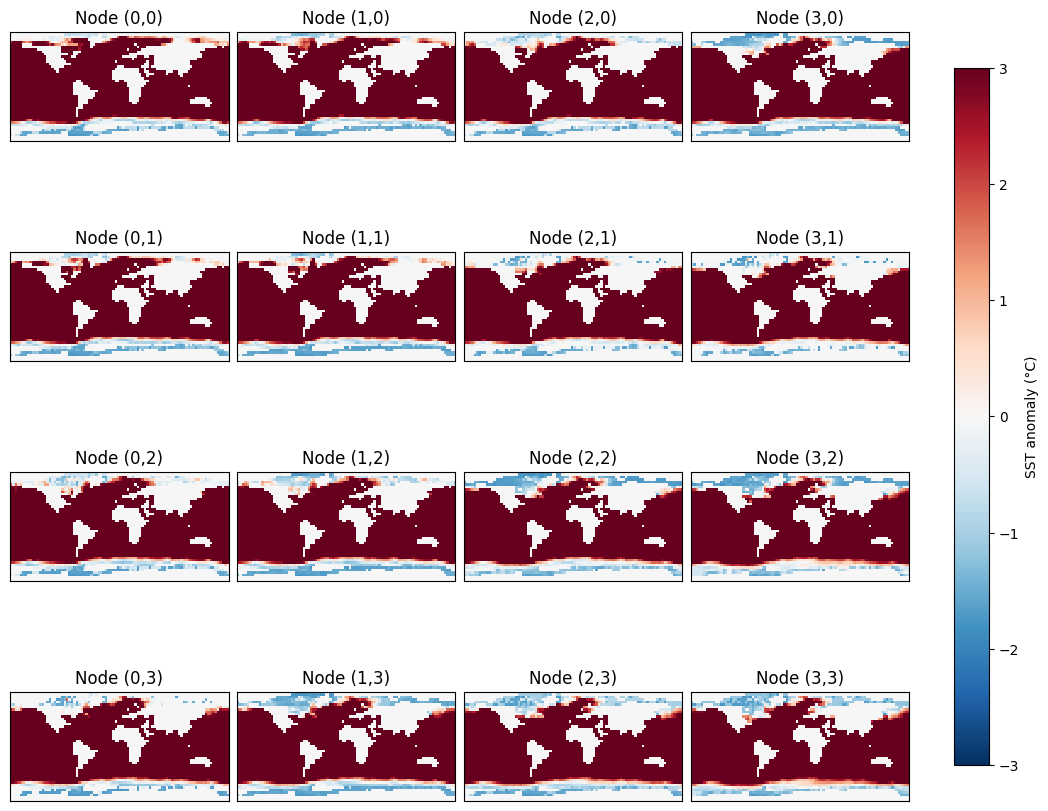

In [ ]:
# ============================
# Visualize: SOM prototypes as 2-D maps
# ============================
fig, axes = plt.subplots(SOM_Y, SOM_X, figsize=(2.6*SOM_X, 2.2*SOM_Y), constrained_layout=True)
for x in range(SOM_X):
    for y in range(SOM_Y):
        w = som.get_weights()[x, y].reshape(n_lat, n_lon)
        ax = axes[y, x] if SOM_Y>1 else axes[x]
        im = ax.imshow(w[::-1, :], cmap='RdBu_r', vmin=-3, vmax=3, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'Node ({x},{y})')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='SST anomaly (°C)')
plt.show()


## Step 10 — Best Matching Units (BMUs) time series

Computes the **BMU** (node index) for each date’s vector. This yields a **time series of regime IDs**, useful to study pattern frequency and transitions.


In [ ]:
# ============================
# Time series of node occupancy
# ============================
occ = pd.Series(bmu_ids).value_counts().sort_index()
print('Node occupancy counts:\n', occ)

ts = pd.DataFrame({'date': meta_dates, 'node_id': bmu_ids})
# display(ts)

# (Optional) Save outputs (CSV)
ts.to_csv('som_bmu_timeseries.csv', index=False)

Node occupancy counts:
 0     24
1     14
2      9
3      7
4     36
5     16
6     21
7     23
8     30
9      7
10    23
11    30
12    23
13     7
14    30
15    60
Name: count, dtype: int64


## Step 11 — Save Trained SOM Model and Outputs

This cell packages all results from the **Self-Organising Map (SOM)** experiment into a single, portable archive on **Google Drive**.  
It preserves the trained model, spatial prototypes, metadata, BMU (Best-Matching-Unit) time series, and a high-resolution global atlas for visual inspection.



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-304356382.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
/tmp/ipython-input-304356382.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z",


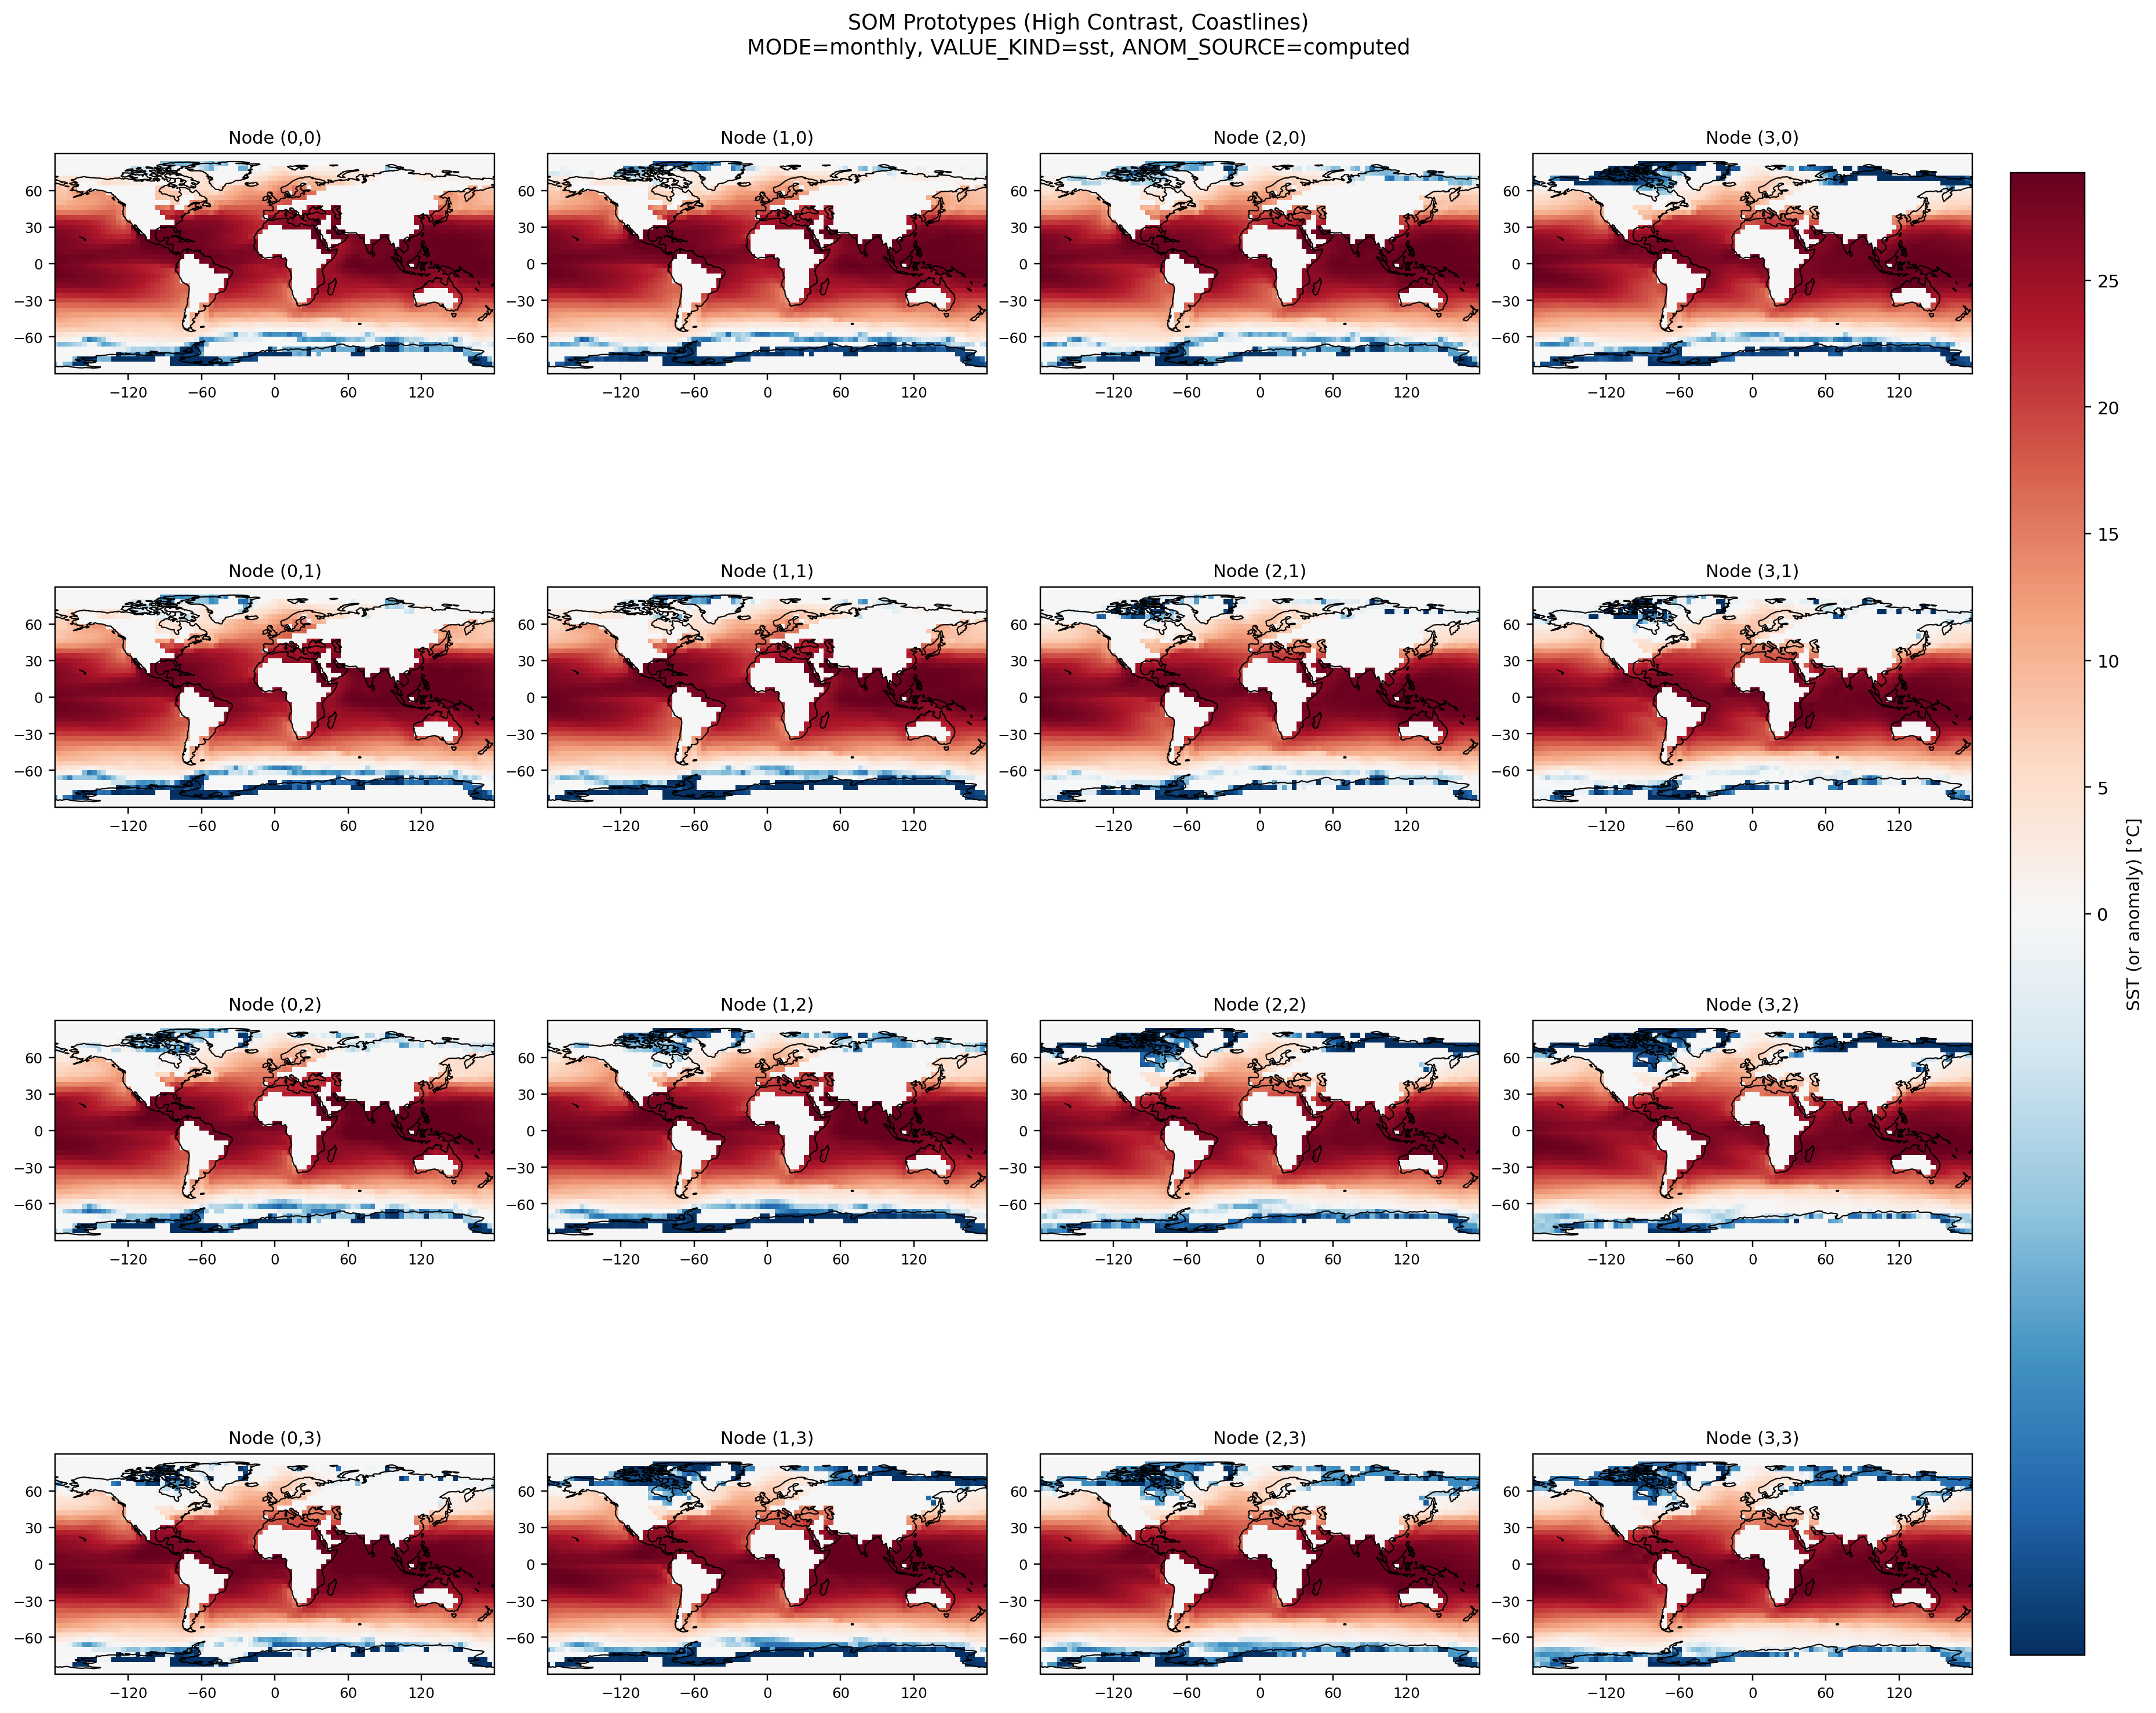

Saved atlas: /content/drive/MyDrive/SST_SOM/SOM_monthly_sst_computed_BT-overall_BS-per_pixel_1982-01-01_2011-12-31_deg4.0_SOM4x4_it20000_20251114T080741Z/som_prototypes_atlas_coastlines.png
Saved package: /content/drive/MyDrive/SST_SOM/SOM_monthly_sst_computed_BT-overall_BS-per_pixel_1982-01-01_2011-12-31_deg4.0_SOM4x4_it20000_20251114T080741Z.zip


In [ ]:
# =========================
# Step 11 — Save Trained SOM Model and Outputs (with full settings)
# =========================
# This cell saves:
#   - SOM weights + prototypes + grid (som_model.npz)
#   - BMU time series (som_bmu_timeseries.csv)
#   - Experiment metadata including ALL Step-3 settings (metadata.json)
#   - High-res prototype atlas with coastlines (som_prototypes_atlas_coastlines.png)
#   - A ZIP archive containing the entire experiment folder

from google.colab import drive
drive.mount('/content/drive')

import os, json, shutil, numpy as np, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# ---- Helper: build a unique experiment name including key settings ----
def make_experiment_slug(mode, value_kind, anom_source,
                         baseline_temporal, baseline_spatial,
                         start, end, deg, som_x, som_y, iters):
    ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
    return (
        f"SOM_{mode}_{value_kind}_{anom_source}_"
        f"BT-{baseline_temporal}_BS-{baseline_spatial}_"
        f"{start}_{end}_deg{deg}_SOM{som_x}x{som_y}_it{iters}_{ts}"
    )

EXP = make_experiment_slug(
    MODE,
    VALUE_KIND,
    ANOM_SOURCE,
    BASELINE_TEMPORAL,
    BASELINE_SPATIAL,
    START,
    END,
    TARGET_DEG,
    SOM_X,
    SOM_Y,
    SOM_ITERS,
)

BASE = f"/content/drive/MyDrive/SST_SOM/{EXP}"
Path(BASE).mkdir(parents=True, exist_ok=True)

# ---- 1) Save SOM weights & prototypes ----
weights = som.get_weights()                                 # (SOM_X, SOM_Y, n_features)
protos  = weights.reshape(SOM_X, SOM_Y, n_lat, n_lon)       # (SOM_X, SOM_Y, n_lat, n_lon)

np.savez_compressed(
    f"{BASE}/som_model.npz",
    weights=weights,
    prototypes=protos,
    lon_edges=np.asarray(lon_edges, dtype=np.float32),
    lat_edges=np.asarray(lat_edges, dtype=np.float32),
)

# ---- 2) Build metadata (includes ALL Step-3 settings) ----
meta = {
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "experiment": EXP,

    # SOM configuration
    "som": {
        "som_x": int(SOM_X),
        "som_y": int(SOM_Y),
        "som_iters": int(SOM_ITERS),
        "n_features": int(weights.shape[-1]),
    },

    # Grid / stack info
    "grid": {
        "n_lat": int(n_lat),
        "n_lon": int(n_lon),
        "target_deg": float(TARGET_DEG),
    },

    # High-level data description
    "data": {
        "dataset": "NOAA/CDR/OISST/V2_1",
        "value_kind": VALUE_KIND,          # 'sst' or 'anom'
        "anom_source": ANOM_SOURCE,        # 'builtin' or 'computed'
        "mode": MODE,                      # 'daily' or 'monthly'
        "start": START,
        "end": END,
    },

    # Step-3 user settings (full configuration)
    "settings": {
        "MODE": MODE,
        "VALUE_KIND": VALUE_KIND,
        "ANOM_SOURCE": ANOM_SOURCE,
        "BASELINE_TEMPORAL": BASELINE_TEMPORAL,
        "BASELINE_SPATIAL": BASELINE_SPATIAL,
        "BASELINE_START": BASELINE_START,
        "BASELINE_END": BASELINE_END,
        "ICE_THRESH": float(ICE_THRESH),
        "TARGET_DEG": float(TARGET_DEG),
        "START": START,
        "END": END,
    },

    # Extra notes about preprocessing
    "preprocessing": {
        "sst_units": "degC",
        "masking": f"ice <= {ICE_THRESH}%, ocean-only, sanity filters applied",
        "flatten_order": "row-major (lat, lon)",
        "stack_shape": list(stack.shape),  # [T, n_lat, n_lon]
    },

    "notes": "SOM trained on OISST fields (SST or anomalies) according to Step-3 settings.",
}

with open(f"{BASE}/metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

# ---- 3) Save BMU time series with commented metadata header ----
bmu_csv = f"{BASE}/som_bmu_timeseries.csv"
meta_header = [f"# {k}: {v}" for k, v in meta.items()]

with open(bmu_csv, "w") as f:
    f.write("\n".join(meta_header) + "\n")
    ts.to_csv(f, index=False)  # FIX: moved inside the with-block
  # ts is your BMU time series DataFrame

# ---- 4) Big high-contrast atlas with coastlines (and show it) ----
!pip -q install cartopy

import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm

Lon, Lat = np.meshgrid(lon_edges, lat_edges)

# Robust colour limits for all prototypes
all_vals = protos.reshape(-1)
all_vals = all_vals[~np.isnan(all_vals)]
vmin = np.percentile(all_vals, 2)
vmax = np.percentile(all_vals, 98)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

fig_w = 4.2 * SOM_X
fig_h = 3.4 * SOM_Y
dpi   = 220

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=SOM_Y, ncols=SOM_X,
    figsize=(fig_w, fig_h), dpi=dpi,
    subplot_kw={"projection": proj},
    constrained_layout=True,
)
axes = np.atleast_2d(axes)

pc_last = None
for x in range(SOM_X):
    for y in range(SOM_Y):
        ax = axes[y, x]
        ax.set_global()
        pc_last = ax.pcolormesh(
            Lon, Lat, protos[x, y],
            transform=proj,
            cmap="RdBu_r",
            norm=norm,
            shading="auto",
        )
        ax.coastlines(linewidth=0.7, color="black")
        ax.set_xticks([-120, -60, 0, 60, 120], crs=proj)
        ax.set_yticks([-60, -30, 0, 30, 60], crs=proj)
        ax.tick_params(labelsize=8)
        ax.set_title(f"Node ({x},{y})", fontsize=10)

cbar = fig.colorbar(pc_last, ax=axes.ravel().tolist(), shrink=0.86, pad=0.02)
cbar.set_label("SST (or anomaly) [°C]", fontsize=10)

title_line = (
    f"SOM Prototypes (High Contrast, Coastlines)\n"
    f"MODE={MODE}, VALUE_KIND={VALUE_KIND}, ANOM_SOURCE={ANOM_SOURCE}"
)
fig.suptitle(title_line, fontsize=12, y=1.02)

atlas_path = f"{BASE}/som_prototypes_atlas_coastlines.png"
fig.savefig(atlas_path, dpi=dpi, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved atlas:", atlas_path)

# ---- 5) Zip the entire experiment folder ----
zip_path = f"/content/drive/MyDrive/SST_SOM/{EXP}.zip"
shutil.make_archive(zip_path.replace(".zip", ""), "zip", BASE)
print("Saved package:", zip_path)
